# Multi-head Attention Implementation

This notebook provides a step-by-step implementation and demonstration of the Multi-head Attention mechanism, a crucial component of Transformer models used in various sequence-to-sequence tasks like machine translation and natural language understanding.

Multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions. This process involves projecting queries, keys, and values into multiple "heads" or subspaces, performing attention independently in each head, and then concatenating the results.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

In [40]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# These are the standard libraries for numerical operations and neural networks in Python.

## 1. Initial Setup and Input Generation

First, we import the necessary PyTorch libraries and define some basic parameters that will be used throughout the implementation. We then create a sample input tensor `x` to simulate a batch of sequences.

In [3]:
sequence_length = 4 # My name is Onkar
batch_size = 1
input_dim = 512 # vector input
d_model = 512
x = torch.randn( (batch_size, sequence_length, input_dim) )

In [41]:
sequence_length = 4 # Represents the number of tokens/steps in a sequence (e.g., words in a sentence)
batch_size = 1      # Number of independent sequences processed in parallel
input_dim = 512     # Dimension of the input embedding for each token
d_model = 512       # Dimension of the model's internal representation (often equal to input_dim)

# Create a random input tensor 'x' with the defined dimensions.
# This simulates a batch of sequences where each token is represented by a vector of input_dim.
x = torch.randn( (batch_size, sequence_length, input_dim) )

In [4]:
x.size()

torch.Size([1, 4, 512])

## 2. Query, Key, Value (QKV) Projection

Before computing attention, the input `x` is transformed into three different representations: Query (Q), Key (K), and Value (V). These transformations are typically done using linear layers. For efficiency, Q, K, and V are often projected together and then split.

In [42]:
x.size() # Display the shape of the input tensor, confirming its dimensions.

torch.Size([1, 4, 512])

In [5]:
qkv_layer = nn.Linear(input_dim , 3 * d_model)

In [43]:
num_heads = 8 # Number of attention heads. This will be used later.

# Define a linear layer to project the input into concatenated Q, K, and V vectors.
# The output dimension is 3 * d_model because we are generating Q, K, and V, each of dimension d_model.
qkv_layer = nn.Linear(input_dim , 3 * d_model)

In [6]:
qkv = qkv_layer(x)

In [44]:
# Apply the linear projection to the input tensor.
qkv = qkv_layer(x)

In [7]:
qkv.shape

torch.Size([1, 4, 1536])

In [45]:
qkv.shape # Display the shape of the projected QKV tensor.

torch.Size([1, 4, 1536])

Text(0.5, 1.0, 'qkv distribution')

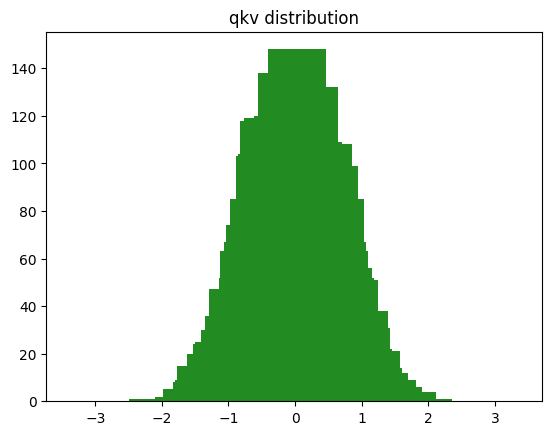

In [8]:
import matplotlib.pyplot as plt
y_val = torch.histc(qkv, bins=200, min=-3, max=3)
x_val = np.arange(-1, 1, 0.01) * 3
plt.bar(x_val, y_val, align='center', color=['forestgreen'])
plt.title('qkv distribution')

## 3. Multi-head Reshaping and Permutation

For multi-head attention, the projected QKV tensor needs to be reshaped to separate the individual attention heads. This allows each head to process information independently. After reshaping, a permutation is applied to arrange the dimensions in a way that facilitates parallel computation across heads.

Text(0.5, 1.0, 'qkv distribution')

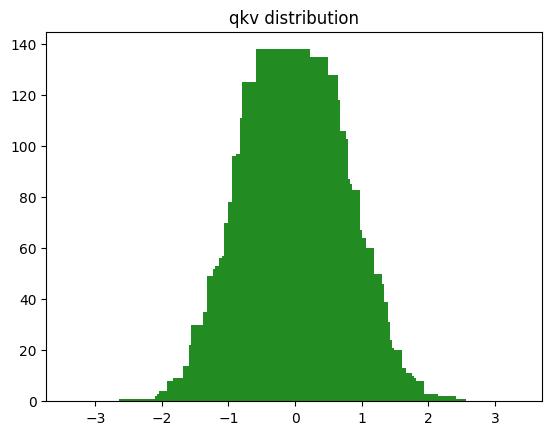

In [46]:
import matplotlib.pyplot as plt

# Visualize the distribution of values within the QKV tensor.
# This helps to see how the linear transformation has affected the data.
y_val = torch.histc(qkv, bins=200, min=-3, max=3)
x_val = np.arange(-1, 1, 0.01) * 3
plt.bar(x_val, y_val, align='center', color=['forestgreen'])
plt.title('qkv distribution')

In [9]:
num_heads = 8
head_dim = d_model // num_heads
qkv = qkv.reshape(batch_size, sequence_length, num_heads, 3 * head_dim)

In [47]:
# Calculate the dimension of each head's Q, K, or V vector.
# d_model is divided by num_heads to ensure the total dimension remains d_model when concatenated.
head_dim = d_model // num_heads

# Reshape the qkv tensor to separate the multiple attention heads.
# The new shape organizes the data such that each head has its own QKV representation.
qkv = qkv.reshape(batch_size, sequence_length, num_heads, 3 * head_dim)

In [10]:
qkv.shape

torch.Size([1, 4, 8, 192])

In [48]:
qkv.shape # Display the shape after reshaping for multi-head processing.

torch.Size([1, 4, 8, 192])

In [11]:
qkv = qkv.permute(0, 2, 1, 3) # [batch_size, num_heads, sequence_length, 3*head_dim]
qkv.shape

torch.Size([1, 8, 4, 192])

In [49]:
# Permute the dimensions to bring 'num_heads' to the second position.
# This structure (batch_size, num_heads, sequence_length, feature_dim) is standard for multi-head attention,
# enabling independent processing for each head.
qkv = qkv.permute(0, 2, 1, 3) # [batch_size, num_heads, sequence_length, 3*head_dim]
qkv.shape

torch.Size([1, 8, 4, 192])

In [12]:
q, k, v = qkv.chunk(3, dim=-1)
q.shape, k.shape, v.shape

(torch.Size([1, 8, 4, 64]),
 torch.Size([1, 8, 4, 64]),
 torch.Size([1, 8, 4, 64]))

## 4. Scaled Dot-Product Attention (Manual Steps)

Now, we perform the core attention calculation for each head. This involves:

1.  **Dot product** between Query and Key to get raw attention scores.
2.  **Scaling** the scores by the square root of the key dimension to prevent vanishing gradients.
3.  **Applying a mask** (optional, for decoder attention) to prevent attending to future tokens.
4.  **Applying softmax** to get attention probabilities.
5.  **Multiplying by Value** to get the weighted sum of values, representing the attention output.

In [50]:
# Split the concatenated QKV tensor into individual Query (q), Key (k), and Value (v) tensors.
# Each now has the shape (batch_size, num_heads, sequence_length, head_dim).
q, k, v = qkv.chunk(3, dim=-1)
q.shape, k.shape, v.shape

(torch.Size([1, 8, 4, 64]),
 torch.Size([1, 8, 4, 64]),
 torch.Size([1, 8, 4, 64]))

In [14]:
import math
d_k = q.size()[-1]
scaled = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
scaled.shape

torch.Size([1, 8, 4, 4])

In [51]:
import math

# Get the dimension of the key vectors (d_k) for scaling.
d_k = q.size()[-1]

# Calculate the raw attention scores by taking the dot product of Q and K transpose.
# Then, scale these scores by 1/sqrt(d_k) to stabilize training.
scaled = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
scaled.shape

torch.Size([1, 8, 4, 4])

In [15]:
k.T.shape

/tmp/ipykernel_2592/3717780648.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  k.T.shape


torch.Size([64, 4, 8, 1])

In [52]:
k.T.shape # This is an example to show how .T (transpose) works on tensors, but it's not the correct way for multi-dimensional tensors. The warning indicates this.

torch.Size([64, 4, 8, 1])

In [16]:
y = torch.randn(2, 3)
torch.transpose(y, 0, 1)

tensor([[-0.3556, -0.2106],
        [ 1.1605, -0.8061],
        [-0.4348,  0.5617]])

In [53]:
y = torch.randn(2, 3)
torch.transpose(y, 0, 1) # Correct way to transpose specific dimensions.

tensor([[-0.2705, -0.0032],
        [-0.5558, -0.7721],
        [-0.2612,  0.1837]])

In [17]:
torch.transpose(y, 1, 0)

tensor([[-0.3556, -0.2106],
        [ 1.1605, -0.8061],
        [-0.4348,  0.5617]])

In [54]:
torch.transpose(y, 1, 0) # Same as above, just showing the order of dimensions for clarity.

tensor([[-0.2705, -0.0032],
        [-0.5558, -0.7721],
        [-0.2612,  0.1837]])

In [18]:
k.transpose(-1, -2) == k.transpose(-2, -1)

tensor([[[[True, True, True, True],
          [True, True, True, True],
          [True, True, True, True],
          ...,
          [True, True, True, True],
          [True, True, True, True],
          [True, True, True, True]],

         [[True, True, True, True],
          [True, True, True, True],
          [True, True, True, True],
          ...,
          [True, True, True, True],
          [True, True, True, True],
          [True, True, True, True]],

         [[True, True, True, True],
          [True, True, True, True],
          [True, True, True, True],
          ...,
          [True, True, True, True],
          [True, True, True, True],
          [True, True, True, True]],

         ...,

         [[True, True, True, True],
          [True, True, True, True],
          [True, True, True, True],
          ...,
          [True, True, True, True],
          [True, True, True, True],
          [True, True, True, True]],

         [[True, True, True, True],
          [True, 

In [55]:
k.transpose(-1, -2) == k.transpose(-2, -1) # Confirms that transposing the last two dimensions is equivalent regardless of order.

tensor([[[[True, True, True, True],
          [True, True, True, True],
          [True, True, True, True],
          ...,
          [True, True, True, True],
          [True, True, True, True],
          [True, True, True, True]],

         [[True, True, True, True],
          [True, True, True, True],
          [True, True, True, True],
          ...,
          [True, True, True, True],
          [True, True, True, True],
          [True, True, True, True]],

         [[True, True, True, True],
          [True, True, True, True],
          [True, True, True, True],
          ...,
          [True, True, True, True],
          [True, True, True, True],
          [True, True, True, True]],

         ...,

         [[True, True, True, True],
          [True, True, True, True],
          [True, True, True, True],
          ...,
          [True, True, True, True],
          [True, True, True, True],
          [True, True, True, True]],

         [[True, True, True, True],
          [True, 

In [19]:
k.transpose(-1, -2).shape

torch.Size([1, 8, 64, 4])

In [56]:
k.transpose(-1, -2).shape # Shows the shape after correctly transposing the last two dimensions of K.

torch.Size([1, 8, 64, 4])

In [20]:
mask = torch.full(scaled.size() , float('-inf'))
mask = torch.triu(mask, diagonal=1)
mask[0][1] # mask for input to a single head

tensor([[0., -inf, -inf, -inf],
        [0., 0., -inf, -inf],
        [0., 0., 0., -inf],
        [0., 0., 0., 0.]])

In [57]:
# Create a mask with negative infinity values for upper triangular part.
# This mask is used in decoder self-attention to prevent a token from attending to subsequent tokens.
mask = torch.full(scaled.size() , float('-inf'))
mask = torch.triu(mask, diagonal=1)

# Display a slice of the mask for a single head to see its structure.
mask[0][1] # mask for input to a single head

tensor([[0., -inf, -inf, -inf],
        [0., 0., -inf, -inf],
        [0., 0., 0., -inf],
        [0., 0., 0., 0.]])

In [21]:
(scaled + mask)[0][0]

tensor([[-0.0533,    -inf,    -inf,    -inf],
        [-0.1117,  0.0426,    -inf,    -inf],
        [ 0.3015,  0.4905, -0.0502,    -inf],
        [ 0.5750,  0.4266, -0.1967,  0.3214]], grad_fn=<SelectBackward0>)

In [58]:
# Demonstrate the effect of adding the mask to the scaled scores.
# Positions that are masked (upper triangle) become -inf, which will result in 0 after softmax.
(scaled + mask)[0][0]

tensor([[-0.3219,    -inf,    -inf,    -inf],
        [ 0.1004,  0.1582,    -inf,    -inf],
        [ 0.2576,  0.1122, -0.0720,    -inf],
        [-0.0625,  0.6183,  0.1285,  0.1458]], grad_fn=<SelectBackward0>)

In [22]:
scaled += mask

In [59]:
# Apply the mask by adding it to the scaled attention scores.
# This operation modifies the 'scaled' tensor in-place.
scaled += mask

In [23]:
np.exp(0.5596) / (np.exp(0.5596) + np.exp(0.0404))

np.float64(0.6269606805367254)

In [60]:
np.exp(0.5596) / (np.exp(0.5596) + np.exp(0.0404)) # Manual calculation example for softmax.

np.float64(0.6269606805367254)

In [24]:
attention = F.softmax(scaled, dim=-1)

In [61]:
# Apply softmax along the last dimension to get attention probabilities.
# These probabilities indicate how much attention each query pays to each key.
attention = F.softmax(scaled, dim=-1)

In [25]:
attention.shape

torch.Size([1, 8, 4, 4])

In [62]:
attention.shape # Display the shape of the attention weights.

torch.Size([1, 8, 4, 4])

In [26]:
attention[0][0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.4615, 0.5385, 0.0000, 0.0000],
        [0.3435, 0.4149, 0.2416, 0.0000],
        [0.3225, 0.2781, 0.1491, 0.2503]], grad_fn=<SelectBackward0>)

In [63]:
attention[0][0] # Display sample attention weights for the first batch and first head.

tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.4856, 0.5144, 0.0000, 0.0000],
        [0.3870, 0.3346, 0.2783, 0.0000],
        [0.1846, 0.3646, 0.2234, 0.2273]], grad_fn=<SelectBackward0>)

In [27]:
values = torch.matmul(attention, v)
values.shape

torch.Size([1, 8, 4, 64])

## 5. `scaled_dot_product` Function

To make the attention calculation reusable, we encapsulate the steps from section 4 into a dedicated function `scaled_dot_product`. This function takes the Query, Key, Value tensors, and an optional mask, and returns the aggregated values and the attention weights.

In [64]:
# Multiply the attention weights by the Value tensor to get the weighted sum of values.
# This is the output of the attention mechanism for each head.
values = torch.matmul(attention, v)
values.shape

torch.Size([1, 8, 4, 64])

In [28]:
import math

def scaled_dot_product(q, k, v, mask=None):
    d_k = q.size()[-1]
    scaled = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(d_k)
    if mask is not None:
        scaled += mask
    attention = F.softmax(scaled, dim=-1)
    values = torch.matmul(attention, v)
    return values, attention

In [65]:
import math

def scaled_dot_product(q, k, v, mask=None):
    # Calculate d_k, the dimension of the key vectors, for scaling
    d_k = q.size()[-1]

    # Compute raw attention scores (Q * K^T) and scale them
    scaled = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(d_k)

    # Apply mask if provided (e.g., for decoder attention to prevent attending to future tokens)
    if mask is not None:
        scaled += mask

    # Apply softmax to get attention probabilities (weights)
    attention = F.softmax(scaled, dim=-1)

    # Multiply attention weights by Value tensor to get the aggregated output
    values = torch.matmul(attention, v)

    return values, attention

In [29]:
values, attention = scaled_dot_product(q, k, v, mask=mask)

In [66]:
# Demonstrate the usage of the 'scaled_dot_product' function with our previously defined Q, K, V, and mask.
values, attention = scaled_dot_product(q, k, v, mask=mask)

In [30]:
attention.shape

torch.Size([1, 8, 4, 4])

In [67]:
attention.shape # Verify the shape of the attention weights returned by the function.

torch.Size([1, 8, 4, 4])

In [31]:
attention[0][0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.4615, 0.5385, 0.0000, 0.0000],
        [0.3435, 0.4149, 0.2416, 0.0000],
        [0.3225, 0.2781, 0.1491, 0.2503]], grad_fn=<SelectBackward0>)

In [68]:
attention[0][0] # Display sample attention weights, confirming consistency with manual steps.

tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.4856, 0.5144, 0.0000, 0.0000],
        [0.3870, 0.3346, 0.2783, 0.0000],
        [0.1846, 0.3646, 0.2234, 0.2273]], grad_fn=<SelectBackward0>)

In [32]:
values.size()

torch.Size([1, 8, 4, 64])

## 6. Output Reshaping and Final Linear Layer

After computing the attention output for each head, these outputs are concatenated and then passed through a final linear layer. This layer projects the concatenated output back into the desired `d_model` dimension, representing the final output of the multi-head attention block.

In [69]:
values.size() # Verify the shape of the aggregated values returned by the function.

torch.Size([1, 8, 4, 64])

In [33]:
values = values.reshape(batch_size, sequence_length, num_heads * head_dim)
values.size()

torch.Size([1, 4, 512])

In [70]:
# Reshape the 'values' tensor by concatenating the outputs from all heads.
# This combines the information processed by each head back into a single tensor of dimension d_model.
values = values.reshape(batch_size, sequence_length, num_heads * head_dim)
values.size()

torch.Size([1, 4, 512])

In [34]:
linear_layer = nn.Linear(d_model, d_model)

In [71]:
# Define a final linear layer (output projection) that maps the concatenated multi-head output
# back to the model's expected dimension (d_model).
linear_layer = nn.Linear(d_model, d_model)

In [35]:
out = linear_layer(values)

In [72]:
# Apply the final linear layer to the aggregated values.
out = linear_layer(values)

In [36]:
out.shape

torch.Size([1, 4, 512])

In [73]:
out.shape # Display the shape of the final output, which should be (batch_size, sequence_length, d_model).

torch.Size([1, 4, 512])

In [37]:
out

tensor([[[ 0.1205,  0.0392, -0.2690,  ..., -0.2344, -0.1756,  0.0999],
         [-0.4169,  0.2051, -0.3692,  ...,  0.2575,  0.0468,  0.1873],
         [-0.2365, -0.1297,  0.2467,  ...,  0.0600, -0.2033, -0.1489],
         [ 0.1276, -0.1003, -0.2725,  ...,  0.2133, -0.0321, -0.1280]]],
       grad_fn=<ViewBackward0>)

## 7. `MultiheadAttention` Class

This section combines all the previous steps into a single, reusable `nn.Module` class called `MultiheadAttention`. This class encapsulates the entire multi-head attention mechanism, making it easy to integrate into larger Transformer architectures.

The `forward` method orchestrates the sequence of operations: QKV projection, reshaping for heads, splitting QKV, performing scaled dot-product attention, concatenating head outputs, and finally, applying the output linear projection.

In [74]:
out # Display the final output tensor.

tensor([[[ 0.1936, -0.0714,  0.4541,  ..., -0.0655,  0.5690, -0.1049],
         [-0.0991, -0.1671,  0.3354,  ...,  0.1553, -0.0072,  0.0877],
         [ 0.1158,  0.1511,  0.1572,  ...,  0.1526, -0.2640,  0.0862],
         [ 0.3689,  0.0709,  0.2993,  ...,  0.2903, -0.1401,  0.1908]]],
       grad_fn=<ViewBackward0>)

In [38]:
import torch
import torch.nn as nn
import math

def scaled_dot_product(q, k, v, mask=None):
    d_k = q.size()[-1]
    scaled = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(d_k)
    if mask is not None:
        scaled += mask
    attention = F.softmax(scaled, dim=-1)
    values = torch.matmul(attention, v)
    return values, attention

class MultiheadAttention(nn.Module):

    def __init__(self, input_dim, d_model, num_heads):
        super().__init__()
        self.input_dim = input_dim
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.qkv_layer = nn.Linear(input_dim , 3 * d_model)
        self.linear_layer = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        batch_size, sequence_length, input_dim = x.size()
        print(f"x.size(): {x.size()}")
        qkv = self.qkv_layer(x)
        print(f"qkv.size(): {qkv.size()}")
        qkv = qkv.reshape(batch_size, sequence_length, self.num_heads, 3 * self.head_dim)
        print(f"qkv.size(): {qkv.size()}")
        qkv = qkv.permute(0, 2, 1, 3)
        print(f"qkv.size(): {qkv.size()}")
        q, k, v = qkv.chunk(3, dim=-1)
        print(f"q size: {q.size()}, k size: {k.size()}, v size: {v.size()}, ")
        values, attention = scaled_dot_product(q, k, v, mask)
        print(f"values.size(): {values.size()}, attention.size:{ attention.size()} ")
        values = values.reshape(batch_size, sequence_length, self.num_heads * self.head_dim)
        print(f"values.size(): {values.size()}")
        out = self.linear_layer(values)
        print(f"out.size(): {out.size()}")
        return out


## 8. Demonstration of `MultiheadAttention` Class

This section demonstrates how to instantiate and use the `MultiheadAttention` class. It sets up new parameters for a fresh example, creates a random input tensor, initializes the `MultiheadAttention` module, and then calls its `forward` method. The print statements within the `forward` method provide insights into the tensor shapes at each stage of the attention process.

In [75]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# Re-define the scaled_dot_product function within this cell for self-containment,
# although it was defined earlier.
def scaled_dot_product(q, k, v, mask=None):
    d_k = q.size()[-1]
    scaled = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(d_k)
    if mask is not None:
        scaled += mask
    attention = F.softmax(scaled, dim=-1)
    values = torch.matmul(attention, v)
    return values, attention

class MultiheadAttention(nn.Module):

    def __init__(self, input_dim, d_model, num_heads):
        super().__init__()
        self.input_dim = input_dim
        self.d_model = d_model
        self.num_heads = num_heads
        # Ensure d_model is divisible by num_heads
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.head_dim = d_model // num_heads

        # Linear layer for projecting input into Q, K, and V for all heads combined
        self.qkv_layer = nn.Linear(input_dim , 3 * d_model)

        # Final linear layer to project the concatenated outputs of all heads
        self.linear_layer = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        batch_size, sequence_length, input_dim = x.size()
        print(f"x.size(): {x.size()}")

        # 1. Project input to QKV
        qkv = self.qkv_layer(x)
        print(f"qkv.size() after linear projection: {qkv.size()}")

        # 2. Reshape QKV for multi-head processing
        #    (batch_size, sequence_length, num_heads, 3 * head_dim)
        qkv = qkv.reshape(batch_size, sequence_length, self.num_heads, 3 * self.head_dim)
        print(f"qkv.size() after reshape for heads: {qkv.size()}")

        # 3. Permute dimensions for parallel computation across heads
        #    (batch_size, num_heads, sequence_length, 3 * head_dim)
        qkv = qkv.permute(0, 2, 1, 3)
        print(f"qkv.size() after permute: {qkv.size()}")

        # 4. Split QKV into Q, K, and V
        #    Each will have shape (batch_size, num_heads, sequence_length, head_dim)
        q, k, v = qkv.chunk(3, dim=-1)
        print(f"q size: {q.size()}, k size: {k.size()}, v size: {v.size()}")

        # 5. Perform scaled dot-product attention
        values, attention = scaled_dot_product(q, k, v, mask)
        print(f"values.size() from scaled_dot_product: {values.size()}, attention.size:{ attention.size()} ")

        # 6. Concatenate outputs from all heads
        #    (batch_size, sequence_length, num_heads * head_dim) which is (batch_size, sequence_length, d_model)
        values = values.reshape(batch_size, sequence_length, self.num_heads * self.head_dim)
        print(f"values.size() after concatenating heads: {values.size()}")

        # 7. Apply final linear projection
        out = self.linear_layer(values)
        print(f"out.size() after final linear layer: {out.size()}")

        return out

In [39]:
input_dim = 1024
d_model = 512
num_heads = 8

batch_size = 30
sequence_length = 5
x = torch.randn( (batch_size, sequence_length, input_dim) )

model = MultiheadAttention(input_dim, d_model, num_heads)
out = model.forward(x)

x.size(): torch.Size([30, 5, 1024])
qkv.size(): torch.Size([30, 5, 1536])
qkv.size(): torch.Size([30, 5, 8, 192])
qkv.size(): torch.Size([30, 8, 5, 192])
q size: torch.Size([30, 8, 5, 64]), k size: torch.Size([30, 8, 5, 64]), v size: torch.Size([30, 8, 5, 64]), 
values.size(): torch.Size([30, 8, 5, 64]), attention.size:torch.Size([30, 8, 5, 5]) 
values.size(): torch.Size([30, 5, 512])
out.size(): torch.Size([30, 5, 512])


In [76]:
input_dim = 1024  # Input feature dimension
d_model = 512     # Model dimension (output dimension of multi-head attention)
num_heads = 8     # Number of attention heads

batch_size = 30   # Number of samples in the batch
sequence_length = 5 # Length of each sequence

# Create a new random input tensor for demonstration
x = torch.randn( (batch_size, sequence_length, input_dim) )

# Instantiate the MultiheadAttention model
model = MultiheadAttention(input_dim, d_model, num_heads)

# Pass the input through the model's forward method
# The print statements inside the forward method will show the tensor shapes at each step.
out = model.forward(x)

x.size(): torch.Size([30, 5, 1024])
qkv.size() after linear projection: torch.Size([30, 5, 1536])
qkv.size() after reshape for heads: torch.Size([30, 5, 8, 192])
qkv.size() after permute: torch.Size([30, 8, 5, 192])
q size: torch.Size([30, 8, 5, 64]), k size: torch.Size([30, 8, 5, 64]), v size: torch.Size([30, 8, 5, 64])
values.size() from scaled_dot_product: torch.Size([30, 8, 5, 64]), attention.size:torch.Size([30, 8, 5, 5]) 
values.size() after concatenating heads: torch.Size([30, 5, 512])
out.size() after final linear layer: torch.Size([30, 5, 512])
